# Decision Making in Business

**Project Description**  
A large online retailer has prepared a list of hypotheses aimed at increasing revenue. It is necessary to prioritize the hypotheses, launch an A/B test, and analyze the results.

**Data Description**

*Hypotheses:* `/datasets/hypothesis.csv`

- **Hypothesis** — a brief description of the hypothesis;
- **Reach** — user reach on a 10-point scale;
- **Impact** — impact on users on a 10-point scale;
- **Confidence** — confidence in the hypothesis on a 10-point scale;
- **Efforts** — resource expenditure for testing the hypothesis on a 10-point scale. The higher the Efforts value, the more expensive the hypothesis test.

*Orders:* `/datasets/orders.csv`

- **transactionId** — order identifier;
- **visitorId** — identifier of the user who placed the order;
- **date** — date when the order was placed;
- **revenue** — revenue from the order;
- **group** — A/B test group to which the order belongs.

*Visitors:* `/datasets/visitors.csv`

- **date** — date;
- **group** — A/B test group;
- **visitors** — number of users on the given date in the specified A/B test group.

**Research Process**

- Data loading and preparation;
- Hypothesis prioritization;
- A/B test analysis;
- Conclusion.

In [1]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from pandas.plotting import register_matplotlib_converters
import warnings
from googletrans import Translator

# Converters that allow the use of pandas types in matplotlib
register_matplotlib_converters()

### Data preparation

In [2]:
data = pd.read_csv(r'C:\Users\Vera\Documents\PET Projects\Portfolio\Data Analyst Practicum\eng\datasets\hypothesis.csv')

translator = Translator()

# This function will translate a given text into English
def translate_to_en(text):
    return translator.translate(text, dest='en').text

# Replace the Russian text in the 'Hypothesis' column with its English translation
data['Hypothesis'] = data['Hypothesis'].apply(translate_to_en)

# Display the first rows to verify the result
data.head()

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Add two new channels for attracting traffic, w...",3,10,8,6
1,"Launch your own delivery service, which will r...",2,5,4,10
2,Add blocks of the recommendations of goods to ...,8,3,7,3
3,"Change the structure of categories, which will...",8,3,3,8
4,Change the background of the main page to incr...,3,1,1,1


In [3]:
# Convert all column names to lowercase
data.columns = data.columns.str.lower()
data.head()

,hypothesis,reach,impact,confidence,efforts
0,"Add two new channels for attracting traffic, w...",3,10,8,6
1,"Launch your own delivery service, which will r...",2,5,4,10
2,Add blocks of the recommendations of goods to ...,8,3,7,3
3,"Change the structure of categories, which will...",8,3,3,8
4,Change the background of the main page to incr...,3,1,1,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   hypothesis  9 non-null      object
 1   reach       9 non-null      int64 
 2   impact      9 non-null      int64 
 3   confidence  9 non-null      int64 
 4   efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes


In [5]:
# Dataframe with order data
orders = pd.read_csv(r'C:\Users\Vera\Documents\PET Projects\Portfolio\Data Analyst Practicum\eng\datasets\orders.csv')
orders.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


In [6]:
# Function to convert column names to snake_case
orders.columns = orders.columns.str.replace(r'([A-Z])', r'_\1', regex=True).str.lower().str.strip('_')
orders.head()

,transaction_id,visitor_id,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaction_id  1197 non-null   int64 
 1   visitor_id      1197 non-null   int64 
 2   date            1197 non-null   object
 3   revenue         1197 non-null   int64 
 4   group           1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


In [8]:
# Group data by visitor and count the number of unique groups
grouped_users = orders.groupby('visitor_id')['group'].nunique().reset_index()

# Filter users who belong to both groups
users_in_both_groups = grouped_users[grouped_users['group'] > 1]

# Number of users in both groups
print(f"Number of users in both groups: {len(users_in_both_groups)}")


Number of users in both groups: 58


In [9]:
# Deleting these users' orders from the table
orders = orders[~orders['visitor_id'].isin(users_in_both_groups)]

In [10]:
# Dataframe with visitors data
visitors = pd.read_csv(r'C:\Users\Vera\Documents\PET Projects\Portfolio\Data Analyst Practicum\eng\datasets\visitors.csv')
visitors.head()

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [11]:
visitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [12]:
# Checking for duplicate rows
# Create a list of DataFrame names
names = ['data', 'orders', 'visitors']

# Create a list of DataFrames
dataframes = [data, orders, visitors]

# Print the DataFrame name and the number of duplicate rows
for name, df in zip(names, dataframes):
    print(f'{name}: {df.duplicated().sum()}')


data: 0
orders: 0
visitors: 0


**Conclusion:**

• **Column names** have been converted to lowercase.

• **Missing values:** None were found.

• **Data types:** The 'date' column in the visitors and orders tables needs to be converted to datetime format.

• **Duplicates:** A check for duplicate rows was performed, and none were found.

• **Users in both groups:** 58 users were found to be in both groups. They have been removed.

### Hypothesis Prioritization

The file `/datasets/hypothesis.csv` contains 9 hypotheses for increasing the online store's revenue, with specified parameters: Reach, Impact, Confidence, and Effort.

Apply the **ICE framework** for hypothesis prioritization. Sort them in descending order of priority.

In [13]:
pd.set_option('max_colwidth', 200)

data['ICE'] = (data['impact'] * data['confidence'] / data['efforts']).round(2)

data[['hypothesis', 'ICE']].sort_values(by='ICE', ascending=False)

,hypothesis,ICE
8,Launch a promotion that gives a discount on a product on a birthday,16.20
0,"Add two new channels for attracting traffic, which will attract 30% more users",13.33
7,Add the subscription form for all the main pages to assemble the customer base for email mailings,11.20
6,Show on the main page banners with current promotions and sales in order to increase the conversion,8.00
2,Add blocks of the recommendations of goods to the website of the online store to increase the conversion and average order check,7.00
1,"Launch your own delivery service, which will reduce the delivery time of orders",2.00
5,"Add the page of customer reviews about the store, which will increase the number of orders",1.33
3,"Change the structure of categories, which will increase the conversion, becauseUsers will find the right product faster",1.12
4,Change the background of the main page to increase user involvement,1.00


Apply the **RICE framework** for hypothesis prioritization. Sort them in descending order of priority.

In [14]:
pd.set_option('max_colwidth', 200)
data['RICE'] = data['reach'] * data['impact'] * data['confidence'] / data['efforts']

data[['hypothesis', 'RICE']].sort_values(by='RICE', ascending=False)

,hypothesis,RICE
7,Add the subscription form for all the main pages to assemble the customer base for email mailings,112.0
2,Add blocks of the recommendations of goods to the website of the online store to increase the conversion and average order check,56.0
0,"Add two new channels for attracting traffic, which will attract 30% more users",40.0
6,Show on the main page banners with current promotions and sales in order to increase the conversion,40.0
8,Launch a promotion that gives a discount on a product on a birthday,16.2
3,"Change the structure of categories, which will increase the conversion, becauseUsers will find the right product faster",9.0
1,"Launch your own delivery service, which will reduce the delivery time of orders",4.0
5,"Add the page of customer reviews about the store, which will increase the number of orders",4.0
4,Change the background of the main page to increase user involvement,3.0


In **RICE**, a new parameter — **Reach** — is added. It takes into account how many users or objects the proposed hypothesis will affect. When the Reach parameter is included, hypotheses that impact a larger number of users receive higher RICE scores. This can shift priorities, as hypotheses with lower impact but greater reach may become more important than those with strong impact but affecting fewer users.

**Conclusion:**  
The highest-priority hypothesis is "*Add a subscription form on all main pages...*" (hypothesis with index 7, RICE score - 112).  
Next are hypothesis 2 "*Add recommendation blocks...*" (RICE - 56), followed by "*Add two new channels...*" and "*Display banners with current promotions on the homepage...*" (RICE - 40).

### A/B Test Analysis

We conducted an A/B test and obtained the following results:

#### Build a cumulative revenue chart by groups. Draw conclusions and make assumptions.

In [15]:
orders['date'] = orders['date'].map(
    lambda x: dt.datetime.strptime(x, '%Y-%m-%d')
)

visitors['date'] = visitors['date'].map(
    lambda x: dt.datetime.strptime(x, '%Y-%m-%d')
)

In [16]:
datesGroups = orders[['date', 'group']].drop_duplicates()

ordersAggregated = datesGroups.apply(
    lambda x: orders[
        np.logical_and(
            orders['date'] <= x['date'], orders['group'] == x['group']
        )
    ].agg(
        {
            'date': 'max',
            'group': 'max',
            'transaction_id': 'nunique',
            'visitor_id': 'nunique',
            'revenue': 'sum',
        }
    ),
    axis=1,
).sort_values(by=['date', 'group'])

visitorsAggregated = datesGroups.apply(
    lambda x: visitors[
        np.logical_and(
            visitors['date'] <= x['date'], visitors['group'] == x['group']
        )
    ].agg({'date': 'max', 'group': 'max', 'visitors': 'sum'}),
    axis=1,
).sort_values(by=['date', 'group'])

cumulativeData = ordersAggregated.merge(
    visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group']
)
cumulativeData.columns = [
    'date',
    'group',
    'orders',
    'buyers',
    'revenue',
    'visitors',
]

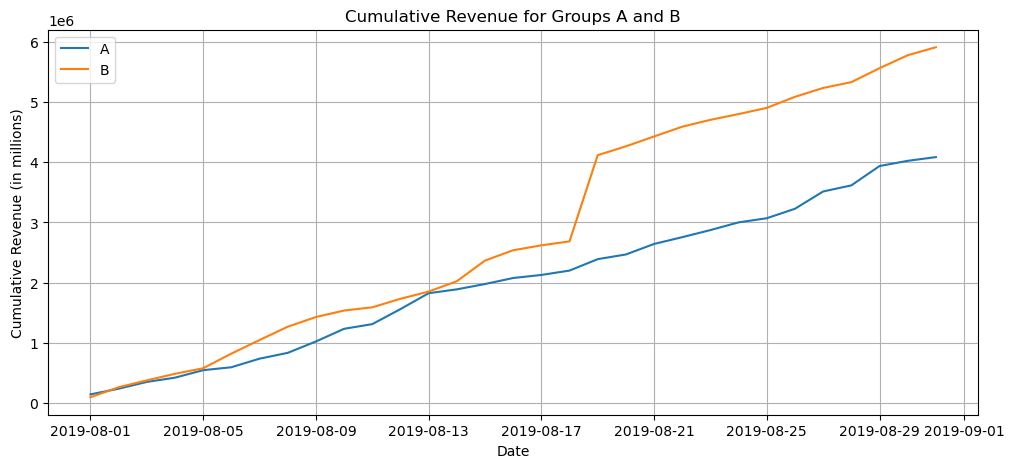

In [17]:
# DataFrame with cumulative number of orders and cumulative revenue by days in group A
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]

# DataFrame with cumulative number of orders and cumulative revenue by days in group B
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]

plt.figure(figsize=(12, 5))
# Plot revenue for group A
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='A')

# Plot revenue for group B
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='B')

plt.title('Cumulative Revenue for Groups A and B')
plt.xlabel('Date')
plt.ylabel('Cumulative Revenue (in millions)')
plt.legend()
plt.grid()
plt.show()

**Conclusion:**  
Cumulative revenue in group B grows slightly faster than in group A from the start. This advantage is maintained throughout the test, and the gap between the groups increases over time. Around August 17, there is a sudden jump in cumulative revenue in group B, most likely due to an abnormally large order or several big orders that significantly boosted the overall revenue in that group. These should be removed in the final analysis.

In group A, revenue growth is more even, without any sudden jumps.

#### Plot a chart of cumulative average order value by groups. Draw conclusions and make assumptions.

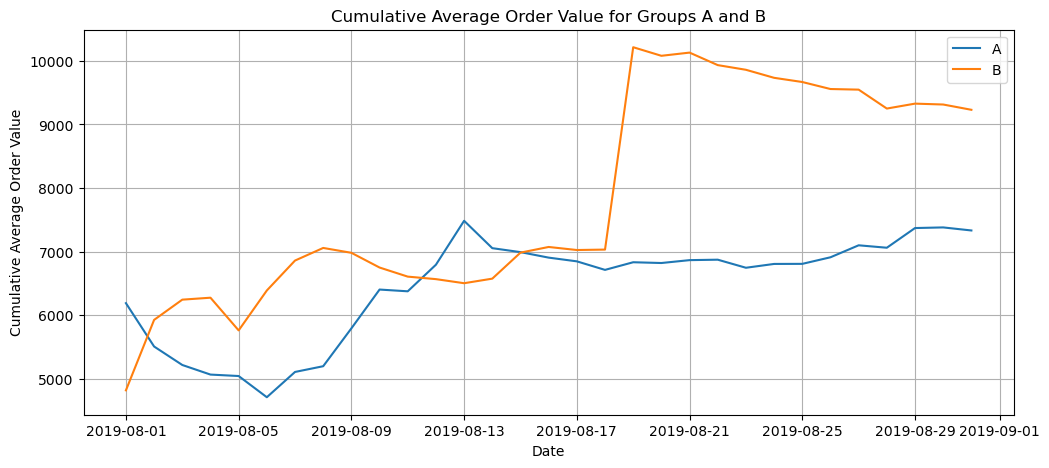

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'] / cumulativeRevenueA['orders'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'] / cumulativeRevenueB['orders'], label='B')

plt.title('Cumulative Average Order Value for Groups A and B')
plt.xlabel('Date')
plt.ylabel('Cumulative Average Order Value')
plt.legend()
plt.grid()
plt.show()

**Conclusion:**  
The cumulative average order value in group A starts to decrease at the beginning of the experiment, reaches a minimum around August 5-6, and then slowly increases, remaining relatively stable until the end of the experiment. In group B, there is a sharp jump in the average order value around August 17, followed by a gradual decline. This jump may be caused by abnormally large orders that significantly impacted the results.

It is likely too early to make decisions based on this metric, or it may be necessary to analyze outliers and possibly exclude them from the data to obtain cleaner results.

#### Plot a chart of the relative change in the cumulative average order value of group B compared to group A. Draw conclusions and make assumptions.

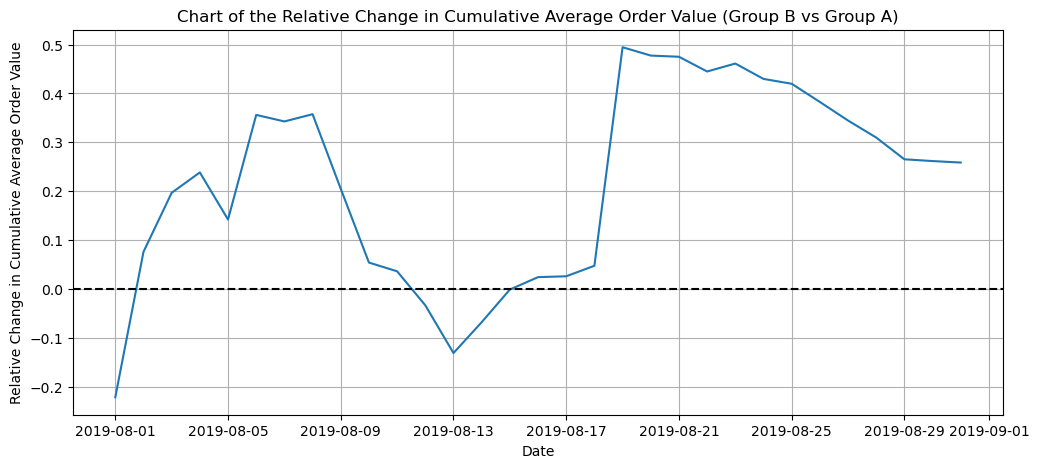

In [21]:
# Merge the data into one DataFrame
mergedCumulativeRevenue = cumulativeRevenueA.merge(
    cumulativeRevenueB, left_on='date', right_on='date', how='left', suffixes=['A', 'B']
)

# Plot the ratio of average order values
plt.figure(figsize=(12, 5))
plt.plot(
    mergedCumulativeRevenue['date'],
    (mergedCumulativeRevenue['revenueB'] / mergedCumulativeRevenue['ordersB']) /
    (mergedCumulativeRevenue['revenueA'] / mergedCumulativeRevenue['ordersA']) - 1
)
# Add X-axis labels

plt.title('Chart of the Relative Change in Cumulative Average Order Value (Group B vs Group A)')
plt.xlabel('Date')
plt.ylabel('Relative Change in Cumulative Average Order Value')
plt.axhline(y=0, color='black', linestyle='--')
plt.grid()
plt.show()


**Conclusion:**  
Group B demonstrates significant fluctuations in average order value compared to group A, which may be due to the presence of outliers. At the beginning of the test, there are notable fluctuations owing to the small amount of data and the sensitivity to individual orders. Around August 13, there was a sharp decrease in group B's average order value relative to group A, likely caused by large orders in group A or a temporary drop in group B. On August 17, a sharp increase in group B is visible due to abnormally large orders. After this, the difference between the groups gradually decreases, but group B's average order value still remains higher.

### Plot a chart of the cumulative average number of orders per visitor by groups. Draw conclusions and make assumptions.

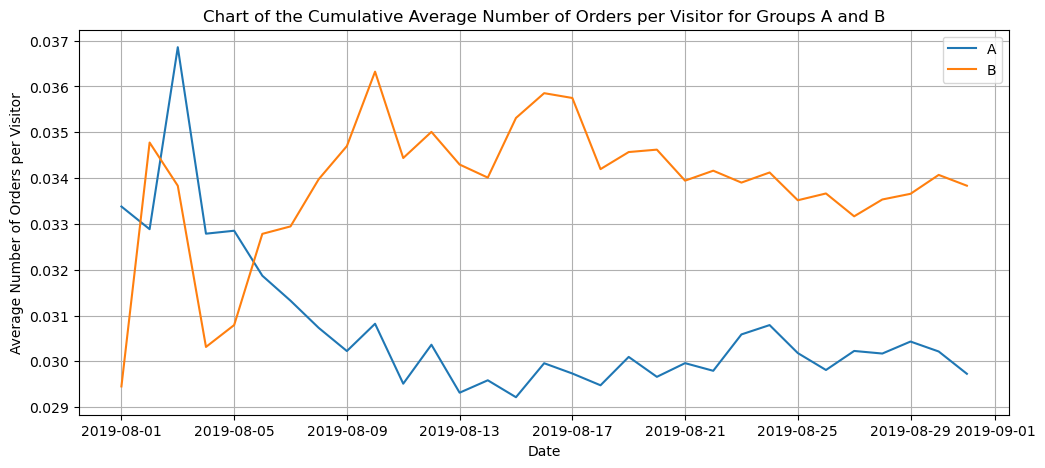

In [22]:
# Calculate the average number of orders per visitor
cumulativeData['conversion'] = cumulativeData['orders'] / cumulativeData['visitors']

# Separate data for group A
cumulativeDataA = cumulativeData[cumulativeData['group'] == 'A']

# Separate data for group B
cumulativeDataB = cumulativeData[cumulativeData['group'] == 'B']

# Plot the charts
plt.figure(figsize=(12, 5))
plt.title('Chart of the Cumulative Average Number of Orders per Visitor for Groups A and B')
plt.xlabel('Date')
plt.ylabel('Average Number of Orders per Visitor')
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B')
plt.legend()
plt.grid()
plt.show()


At the beginning of the test, segment A had a higher cumulative average number of orders, but over time, segment B significantly surpassed segment A. Group B consistently shows a higher number of orders per visitor compared to group A, especially after August 9, where its figures remain high. In group A, a sharp decline is observed after the initial spike, and from the middle of the experiment, its figures remain consistently lower. The sharp changes at the beginning may be due to outliers, which requires further data analysis to exclude anomalous values.

#### Plot a chart of the relative change in the cumulative average number of orders per visitor for group B compared to group A. Draw conclusions and make assumptions.

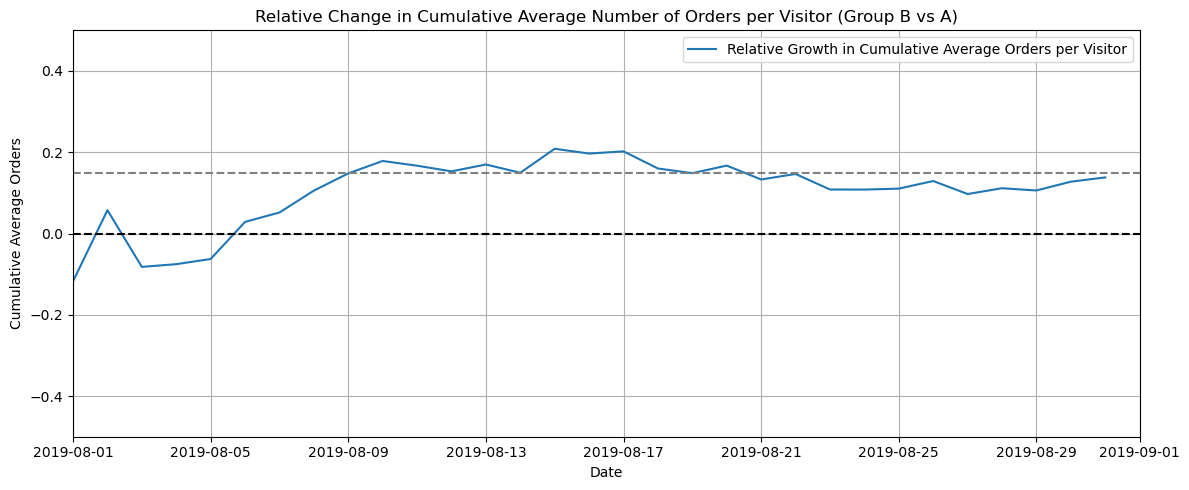

In [23]:
mergedCumulativeConversions = cumulativeDataA[['date', 'conversion']].merge(
    cumulativeDataB[['date', 'conversion']], left_on='date', right_on='date', how='left', suffixes=['A', 'B']
)

# Create a figure with the specified size and title
plt.figure(figsize=(12, 5))
plt.title('Relative Change in Cumulative Average Number of Orders per Visitor (Group B vs A)')

# Plot the chart
plt.plot(
    mergedCumulativeConversions['date'], 
    mergedCumulativeConversions['conversionB'] / mergedCumulativeConversions['conversionA'] - 1, 
    label="Relative Growth in Cumulative Average Orders per Visitor"
)

plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.15, color='grey', linestyle='--')
plt.axis(["2019-08-01", '2019-09-01', -0.5, 0.5])
plt.xlabel('Date')
plt.ylabel('Cumulative Average Orders')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Almost from the very beginning of the test, group B leads on this metric: it continuously improves and stabilizes at around a 15% increase relative to group A.

#### Build a scatter plot of the number of orders per visitor. Draw conclusions and make assumptions.

In [24]:
ordersByUsers = (
    orders.groupby('visitor_id', as_index=False)
    .agg({'transaction_id': 'nunique'})
)

ordersByUsers.columns = ['visitor_id', 'orders']

ordersByUsers.sort_values(by='orders', ascending=False).head(10)

,visitor_id,orders
1023,4256040402,11
591,2458001652,11
569,2378935119,9
487,2038680547,8
44,199603092,5
744,3062433592,5
55,237748145,5
917,3803269165,5
299,1230306981,5
897,3717692402,5


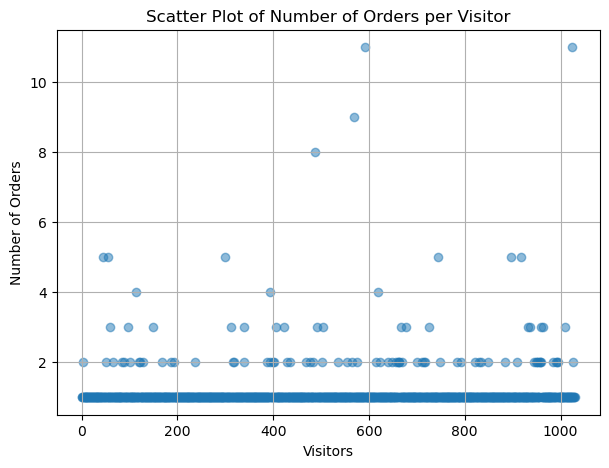

In [25]:
# Series of numbers from 0 to the number of observations in ordersByUsers
x_values = pd.Series(range(0, len(ordersByUsers)))
plt.figure(figsize=(7, 5))
plt.scatter(x_values, ordersByUsers['orders'], alpha=0.5) 
plt.title('Scatter Plot of Number of Orders per Visitor')
plt.xlabel('Visitors')
plt.ylabel('Number of Orders')
plt.grid()
plt.show()


Users who have ordered more than twice are very few. They might be considered anomalies.

Is 2 orders normal or high? Answer this question by computing sample percentiles. Calculate the 95th and 99th percentiles of the number of orders per user. Then, choose a threshold for identifying anomalous users.

#### Calculate the 95th and 99th percentiles of the number of orders per user. Choose a threshold for identifying anomalous users.

In [26]:
# The np.percentile('column', [percentile1, percentile2, percentile3]) method finds percentiles.
print(np.percentile(ordersByUsers['orders'], [90, 95, 99]))

[1. 2. 4.]


Only 10% of users placed more than one order. No more than 5% of users made more than two orders. And no more than 1% of users made more than four orders. The 95th percentile can be set as the threshold for outliers.

#### Build a scatter plot of order values. Make conclusions and assumptions.

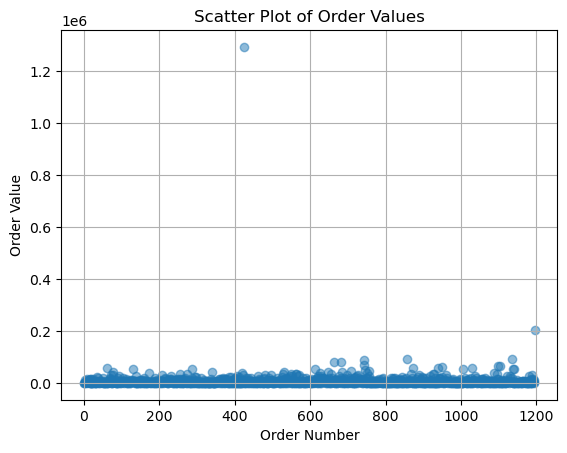

In [27]:
x_values = pd.Series(range(0, len(orders['revenue'])))
plt.scatter(x_values, orders['revenue'], alpha=0.5)
plt.title('Scatter Plot of Order Values')
plt.xlabel('Order Number')
plt.ylabel('Order Value')
plt.grid()
plt.show()


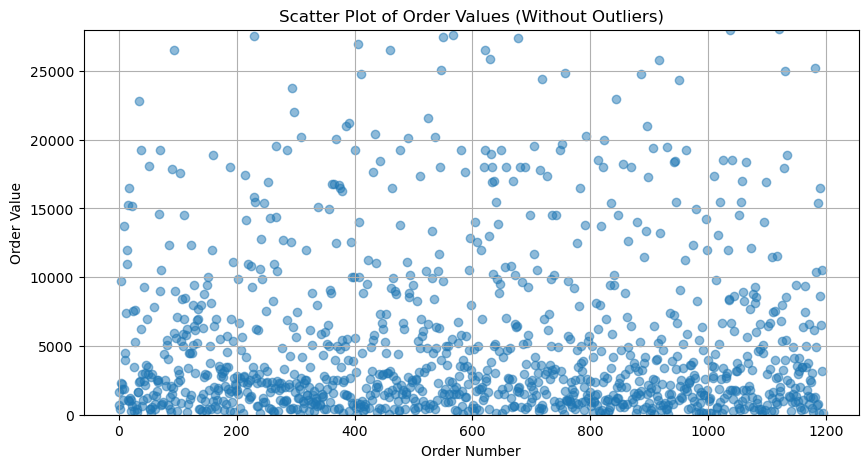

In [28]:
plt.figure(figsize=(10, 5))
plt.scatter(x_values, orders['revenue'], alpha=0.5)
plt.title('Scatter Plot of Order Values (Without Outliers)')
plt.xlabel('Order Number')
plt.ylabel('Order Value')
plt.ylim(0, orders['revenue'].quantile(0.95))  # Limit Y-axis to the 95th percentile
plt.grid()
plt.show()


Most orders have a relatively small value. Two clear outliers stand out: one order around 1.2 million and another around 200 thousand.

#### Calculate the 95th and 99th percentiles of order values. Choose a threshold for identifying anomalous orders.

In [29]:
np.percentile(orders['revenue'], [90, 95, 99])

array([18168. , 28000. , 58233.2])

No more than 5% of orders cost more than 28,000 rubles, and no more than 1% cost more than 58,233 rubles. We will use the 95th percentile as the threshold for outliers.

#### Calculate the statistical significance of the differences in the average number of orders per visitor between the groups based on the "raw" data. Draw conclusions and make assumptions.

Let's formulate the hypotheses.  
**Null hypothesis (H₀):** There are no differences in the average number of orders between the groups.  
**Alternative hypothesis (H₁):** There are differences in the average between the groups.

To test the hypotheses, we will use the Mann-Whitney test, as it is suitable for comparing two independent samples even if the data are not normally distributed. In our case, the number of orders per user may be highly skewed, with outliers and an uneven distribution.

We will adopt the standard significance level of α = 0.05. This means we are willing to accept a 5% chance of erroneously rejecting the null hypothesis.

In [30]:
ordersByUsersA = (
    orders[orders['group'] == 'A']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
ordersByUsersA.columns = ['visitor_id', 'orders']

ordersByUsersB = (
    orders[orders['group'] == 'B']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
ordersByUsersB.columns = ['visitor_id', 'orders'] 

Let's calculate the statistical significance of the difference in the average number of orders between the groups.

In [31]:
sampleA = pd.concat(
    [
        ordersByUsersA['orders'],
        pd.Series(
            0, 
            index=np.arange(visitors[visitors['group'] == 'A']['visitors'].sum() - len(ordersByUsersA['orders'])), 
            name='orders'
        )
    ], 
    axis=0
)

sampleB = pd.concat(
    [
        ordersByUsersB['orders'],
        pd.Series(
            0, 
            index=np.arange(visitors[visitors['group'] == 'B']['visitors'].sum() - len(ordersByUsersB['orders'])), 
            name='orders'
        )
    ], 
    axis=0
)

print('P-value:', "{0:.3f}".format(stats.mannwhitneyu(sampleA, sampleB)[1]))
print('Relative difference between groups:', "{0:.3f}".format((sampleB.mean() / sampleA.mean() - 1)))


P-value: 0.017
Relative difference between groups: 0.138


**Conclusion:**  
The P-value is below the standard threshold of 0.05, which indicates statistically significant differences between groups A and B. This means that the probability of obtaining such differences by chance is less than 1.7%. Therefore, the hypothesis of equal average numbers of orders per visitor between groups A and B can be rejected in favor of the hypothesis that differences exist.

In group B, the average number of orders per visitor increased by 13.8% compared to group A. This significant increase suggests a positive effect of the tested change.

#### Calculate the statistical significance of the differences in the average order value between groups based on the "raw" data. Draw conclusions and make assumptions.

Now let's test the statistical significance of differences in the average order value between segments.  
**Null hypothesis:** There are no differences in the average order value between groups.  
**Alternative hypothesis:** There are differences in the average order value between groups.

To calculate the statistical significance of the differences in the average order value, we will pass the revenue data from the orders to the `mannwhitneyu()` test.  
We will also find the relative differences in the average order value between the groups.

In [32]:
print('p-value:', '{0:.3f}'.format(stats.mannwhitneyu(orders[orders['group']=='A']['revenue'], orders[orders['group']=='B']['revenue'])[1]))
print('Relative increase in average order value for group B:', '{0:.3f}'.format(orders[orders['group']=='B']['revenue'].mean()/orders[orders['group']=='A']['revenue'].mean()-1))

p-value: 0.729
Relative increase in average order value for group B: 0.259


**Conclusion:**  
The p-value is significantly higher than 0.05. In other words, the probability that the observed differences in the average order value between the groups occurred by chance is 72.9%. This value is too high to reject the null hypothesis. Therefore, the null hypothesis—that there is no difference in the average order value between the groups—cannot be rejected.

Despite the lack of statistical significance, an increase in the average order value in group B by 25.9% compared to group A is observed.

#### Remove outliers from the data

Let's remove outliers from the data to more accurately assess the differences between the groups, as they can distort the results and lead to incorrect conclusions.

We will consider users who have placed 3 or more orders or have made an order costing more than 28,000 rubles as outliers. This way, we remove the top 5% of users with the highest number of orders and between 1% and 5% of users with expensive orders. We will slice out the users with more than 2 orders — `usersWithManyOrders` — and the users who placed orders above 28,000 — `usersWithExpensiveOrders`. Then, we will combine them in a table called `abnormalUsers`.

In [33]:
usersWithManyOrders = pd.concat(
    [
        ordersByUsersA[ordersByUsersA['orders'] > np.percentile(ordersByUsers['orders'], 95)]['visitor_id'],
        ordersByUsersB[ordersByUsersB['orders'] > np.percentile(ordersByUsers['orders'], 95)]['visitor_id'],
    ],
    axis=0,
)
usersWithExpensiveOrders = orders[orders['revenue'] > np.percentile(orders['revenue'], 95)]['visitor_id']
abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)

print(abnormalUsers.head(5))

# Determine the total number of outlier users
print('Number of outlier users:', abnormalUsers.shape[0])

1099    148427295
18      199603092
928     204675465
23      237748145
37      249864742
Name: visitor_id, dtype: int64
Number of outlier users: 74


In [34]:
sampleAFiltered = pd.concat(
    [
        ordersByUsersA[
            np.logical_not(ordersByUsersA['visitor_id'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                visitors[visitors['group'] == 'A']['visitors'].sum() - len(ordersByUsersA['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

sampleBFiltered = pd.concat(
    [
        ordersByUsersB[
            np.logical_not(ordersByUsersB['visitor_id'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                visitors[visitors['group'] == 'B']['visitors'].sum() - len(ordersByUsersB['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

#### Calculate the statistical significance of the differences in the average number of orders per visitor between groups based on the "cleaned" data. Draw conclusions and make assumptions.

Let's formulate the hypotheses.  
**Null hypothesis (H₀):** There is no difference in the average number of orders between the groups.  
**Alternative hypothesis (H₁):** There is a difference in the averages between the groups.

To test the hypotheses, we will use the Mann-Whitney test with α = 0.05.

In [35]:
# Apply the Mann-Whitney test to the resulting samples

print('p-value:', '{0:.3f}'.format(stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]))
print('Relative increase in the average number of orders for group B:',
      '{0:.3f}'.format(sampleBFiltered.mean() / sampleAFiltered.mean() - 1))


p-value: 0.013
Relative increase in the average number of orders for group B: 0.173


**Conclusion:**  
The results for the average number of orders have not changed much. The p-value is again below the standard threshold of 0.05, indicating statistically significant differences between groups A and B. The hypothesis of equal mean orders per visitor between groups A and B can be rejected.

In group B, the average number of orders per visitor increased to 17.3%, compared to 13.8% based on the "raw" data.

#### Calculate the statistical significance of the differences in the average order value between groups based on the "cleaned" data. Draw conclusions and make assumptions.


**Null hypothesis (H₀):** There is no difference in the average order value between groups.

**Alternative hypothesis (H₁):** There is a difference in the average order value between groups.

We will pass the revenue data from orders to the Mann-Whitney U test and also calculate the relative difference in the average order value between the groups.

In [36]:
print(
    'p-value:',
    '{0:.3f}'.format(
        stats.mannwhitneyu(
            orders[
                np.logical_and(
                    orders['group'] == 'A',
                    np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
                )
            ]['revenue'],
            orders[
                np.logical_and(
                    orders['group'] == 'B',
                    np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
                )
            ]['revenue'],
        )[1]
    )
)

print(
    'Relative increase in the average order value for group B:',
    "{0:.3f}".format(
        orders[
            np.logical_and(
                orders['group'] == 'B',
                np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        / orders[
            np.logical_and(
                orders['group'] == 'A',
                np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        - 1
    )
)


p-value: 0.738
Relative increase in the average order value for group B: -0.020


**Conclusion:** The p-value is significantly higher than 0.05, almost equally high (0.738 compared to 0.729), which confirms the absence of statistically significant differences. The null hypothesis—that there is no difference in the average order value between the groups—cannot be rejected.

After cleaning the data, the relative increase in the average order value changed from positive (0.259) to negative (-0.020), indicating a slight decrease in the average order value in group B compared to group A.

#### Make a decision based on the test results and explain it. Options:  
1. Stop the test and declare one of the groups as the winner.  
2. Stop the test and record that there are no differences between the groups.  
3. Continue the test.

**Conclusion:**

**Most Prioritized Hypothesis:**  
"Add a subscription form on all main pages..." — hypothesis with index 7 (RICE - 112).  
Next come hypothesis 2 "Add recommendation blocks..." (RICE - 56), "Add two new channels..." and "Display banners with current promotions on the homepage..." (RICE - 40).

**A/B Test Results**

**Cumulative Revenue:**  
In group B, cumulative revenue grows slightly faster than in group A from the very beginning. This advantage is maintained throughout the test, and the gap between the groups increases over time. Around August 17, there is a sudden jump in cumulative revenue in group B. This is most likely due to one abnormally large order or several big orders that substantially increased the overall revenue in the group. In the final analysis, these orders should be removed. In group A, revenue growth is more uniform without any sudden jumps.

**Cumulative Average Order Value:**  
In group A, the cumulative average order value starts to decline at the beginning of the experiment, reaches a minimum around August 5-6, and then begins to slowly increase, remaining relatively stable until the end of the experiment. In group B, there is a sharp jump in the average order value around August 17, followed by a gradual decline. This jump might be caused by abnormally large orders that have significantly affected the results. It is probably too early to make a decision based on this metric, or it may be necessary to analyze outliers and possibly remove them to obtain cleaner results.

Group B demonstrates significant fluctuations in the average order value compared to group A, which may be due to the presence of outliers. At the beginning of the test, there are substantial fluctuations due to the small amount of data and sensitivity to individual orders. Around August 13, there is a sharp decline in group B's average order value relative to group A, likely due to large orders in group A or a temporary drop in group B. On August 17, there is a sharp increase in group B because of abnormally large orders. After this, the difference between the groups gradually decreases, but group B's average order value still remains higher.

**Cumulative Average Number of Orders per Visitor:**  
At the beginning of the test, segment A had a higher cumulative average number of orders, but over time, segment B significantly surpassed segment A. Group B consistently shows a higher number of orders per visitor compared to group A, especially after August 9, where its figures remain at a high level. In group A, a sharp decline is observed after the initial spike, and from the middle of the experiment, its figures remain consistently lower. The sharp changes at the beginning may be due to outliers, which requires additional data analysis to exclude anomalous values.

**Conclusions from the A/B Test:**

Facts:
- There are statistically significant differences in the average number of orders per visitor between groups A and B in both the "raw" and "cleaned" data. The p-value is below the standard threshold of 0.05, indicating statistically significant differences between groups A and B. This suggests that the probability of obtaining such differences by chance is less than 1.7%. Therefore, the hypothesis of equal mean numbers of orders per visitor between groups A and B can be rejected in favor of the hypothesis that differences exist.
- In group B, the average number of orders per visitor increased by 13.8% compared to group A. This substantial increase indicates a positive effect of the tested change.
- There is no statistically significant difference in the average order value between the groups, neither in the "raw" data nor after outlier filtering. After cleaning the data, the relative increase in the average order value changed from positive (0.259) to negative (-0.020), indicating a slight decrease in the average order value in group B compared to group A.
- The chart of the relative change in the cumulative average number of orders per visitor for group B compared to group A shows that, almost from the very beginning of the test, group B leads on this metric, continuously improving and stabilizing at around a 20% increase relative to group A.
- The chart of the relative change in the cumulative average order value for group B compared to group A shows significant fluctuations in group B's average order value compared to group A, which may be due to outliers. In the early phase of the test, there are significant fluctuations due to the small amount of data and sensitivity to individual orders. Around August 13, there is a sharp decline in group B's average order value relative to group A, likely due to large orders in group A or a temporary drop in group B. On August 17, a sharp increase is observed in group B due to abnormally large orders. After this, the difference between the groups gradually decreases, but group B's average order value still remains higher.

**Decision:** Stop the test and declare group B as the winner.

**Justification:**  
The positive impact of the tested change on the number of orders in group B can be considered a win for this metric. The average order value between the groups is not a decisive factor since no significant effect on the overall result was identified. The growth in the number of orders is consistent, and the average order value does not significantly affect the overall picture.